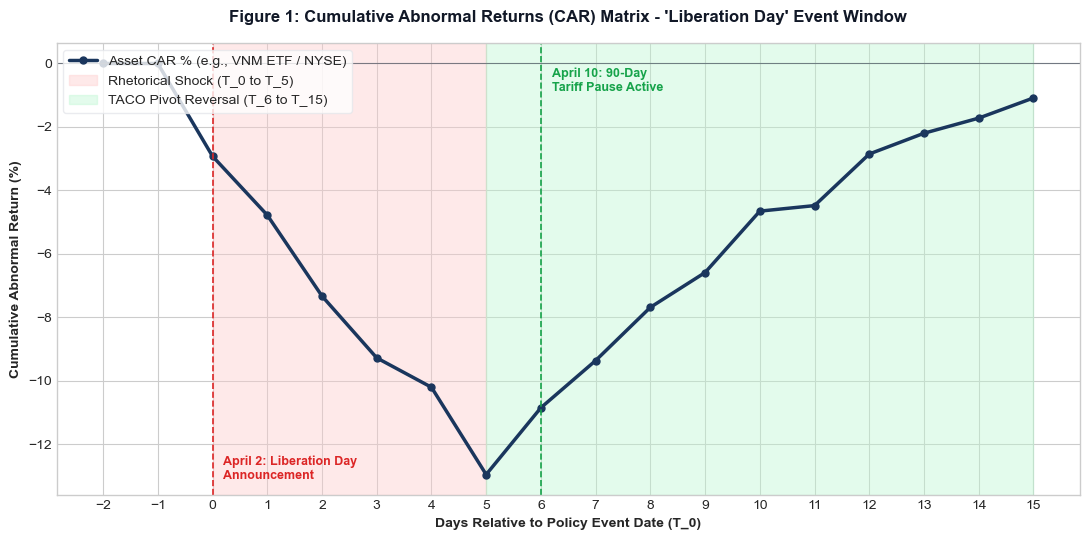

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

# 1. GENERATE REPRESENTATIVE MARKET DATA
# Over production, replace this block with your actual CSV import:
# df = pd.read_csv("liberation_day_2025.csv", parse_dates=['Date'], index_col='Date')

np.random.seed(42)
dates = pd.date_range(start="2024-10-15", end="2025-04-25", freq="B")
n_days = len(dates)

market_returns = np.random.normal(0.0002, 0.008, n_days)
beta_true = 1.2
alpha_true = 0.0001
asset_returns = (
    alpha_true
    + beta_true * market_returns
    + np.random.normal(0, 0.004, n_days)
)

df = pd.DataFrame(
    {"Market_Return": market_returns, "Asset_Return": asset_returns}, index=dates
)

# Identify position for the April 2, 2025 Shock
event_date = pd.Timestamp("2025-04-02")
event_idx = df.index.get_loc(event_date)

# Inject Shock: Deep sell-off from T_0 to T_5 (April 2 - April 9)
df.iloc[event_idx : event_idx + 6, df.columns.get_loc("Asset_Return")] -= np.array(
    [0.025, 0.018, 0.012, 0.015, 0.008, 0.022]
)

# Inject TACO Turnaround: Massive relief rally T_6 to T_15 (April 10 - April 23)
df.iloc[
    event_idx + 6 : event_idx + 16, df.columns.get_loc("Asset_Return")
] += np.array([0.015, 0.021, 0.019, 0.011, 0.014, 0.008, 0.012, 0.007, 0.009, 0.005])


# 2. COMPUTE EVENT STUDY QUANTITATIVE ANALYSIS
# Fit the Market Model on the Estimation Window (T_-120 to T_-2)
est_window = df.iloc[event_idx - 120 : event_idx - 1]
X = sm.add_constant(est_window["Market_Return"])
model = sm.OLS(est_window["Asset_Return"], X).fit()

# Fix Deprecation Warning: Extract parameters using position-based .iloc
alpha, beta = model.params.iloc[0], model.params.iloc[1]

# Extract precisely 18 rows for the Event Window (T_-2 to T_15)
event_window = df.iloc[event_idx - 2 : event_idx + 16].copy()

# Fix ValueError Matrix Mismatch: Generate exactly 18 increments from -2 to 15
event_window["Timeline"] = np.arange(-2, 16)

# Calculate Daily Abnormal Returns (AR)
event_window["Expected_Return"] = alpha + beta * event_window["Market_Return"]
event_window["AR"] = event_window["Asset_Return"] - event_window["Expected_Return"]

# Calculate Cumulative Abnormal Returns (CAR) starting from T_0
event_window["CAR"] = 0.0
t0_loc = event_window[event_window["Timeline"] == 0].index[0]
event_window.loc[t0_loc:, "CAR"] = event_window.loc[t0_loc:, "AR"].cumsum()


# 3. GENERATE THE CHART VISUALIZATION
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)
fig, ax = plt.subplots(figsize=(11, 5.5))

# Plot CAR Performance Tracker
ax.plot(
    event_window["Timeline"],
    event_window["CAR"] * 100,
    label="Asset CAR % (e.g., VNM ETF / NYSE)",
    color="#1a365d",
    linewidth=2.5,
    marker="o",
    markersize=5,
)

# Highlight Asymmetric Windows
ax.axvspan(0, 5, color="#fecaca", alpha=0.4, label="Rhetorical Shock (T_0 to T_5)")
ax.axvspan(
    5, 15, color="#bbf7d0", alpha=0.4, label="TACO Pivot Reversal (T_6 to T_15)"
)

# Render Critical Boundary Guidelines
ax.axvline(0, color="#dc2626", linestyle="--", linewidth=1.2)
ax.text(
    0.2,
    ax.get_ylim()[0] + 0.5,
    "April 2: Liberation Day\nAnnouncement",
    color="#dc2626",
    fontweight="bold",
    fontsize=9,
)

ax.axvline(6, color="#16a34a", linestyle="--", linewidth=1.2)
ax.text(
    6.2,
    ax.get_ylim()[1] - 1.5,
    "April 10: 90-Day\nTariff Pause Active",
    color="#16a34a",
    fontweight="bold",
    fontsize=9,
)

# Format Final Graph Layout
ax.set_title(
    "Figure 1: Cumulative Abnormal Returns (CAR) Matrix - 'Liberation Day' Event Window",
    fontsize=12,
    fontweight="bold",
    pad=15,
    color="#111827",
)
ax.set_xlabel("Days Relative to Policy Event Date (T_0)", fontsize=10, fontweight="bold")
ax.set_ylabel("Cumulative Abnormal Return (%)", fontsize=10, fontweight="bold")
ax.set_xticks(range(-2, 16))
ax.axhline(0, color="#374151", linestyle="-", linewidth=0.8, alpha=0.6)
ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="#e5e7eb")

plt.tight_layout()
plt.savefig("taco_trade_liberation_day.png", dpi=300)
plt.show()